In [1]:
#Packages to Import

#Numerical Elements
from numpy.linalg import norm
import numpy as np
from numpy import dot, array, transpose, diag

#Fun Progress Bar
from tqdm.notebook import tqdm

#Misc System (plotting etc)
import sys
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import pickle
import warnings
warnings.filterwarnings('ignore')


#MCMC Sampliers and Related Utilities
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%run ../MCMC_Sampliers.ipynb



#Plotting Libraries
import matplotlib.pyplot as plt
from numpy.linalg import norm



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})


#Some Code to Compute measures of mixing

import numpy as np
from numpy.fft import rfft, irfft

def ess_OLDE(series: np.ndarray) -> float:
    """
    Effective Sample Size of a 1‑D NumPy array using the
    initial‑positive‑sequence rule (Geyer, 1992).

    Parameters
    ----------
    series : array_like, shape (N,)
        Time‑series values f(X₁),…,f(X_N).

    Returns
    -------
    ess : float
        Estimated effective sample size.
    """
    x = np.asarray(series, dtype=float)
    n = x.size
    x -= x.mean()

    # Autocovariances via FFT: O(N log N)
    fft = rfft(x, n=2*n)
    acov = irfft(fft * np.conjugate(fft))[:n] / n
    rho = acov / acov[0]           # normalised autocorrelation

    # Initial‑positive‑sequence truncation
    pos = np.where(rho[1:] > 0)[0]
    k = pos[-1] + 1 if pos.size else 0   # K = last positive lag

    ess = n / (1 + 2 * rho[1:k+1].sum())
    return ess


import numpy as np

def autocorr_func_1d(x):
    """Compute full autocorrelation function for 1D array x."""
    x = np.asarray(x)
    n = len(x)
    x -= x.mean()
    # unbiased variance
    c0 = np.dot(x, x) / n
    # full autocovariance
    acov = np.correlate(x, x, mode="full")[n-1:] / np.arange(n, 0, -1)
    return acov / c0

def ess(x, max_lag=None):
    """
    Effective Sample Size via initial positive sequence:
      ESS = N / [1 + 2 * sum_{k=1}^K rho_k]
    where K is the last lag before rho_k+rho_{k+1} < 0.
    """
    acf = autocorr_func_1d(x)
    N = len(x)
    # choose max_lag if not set
    if max_lag is None:
        max_lag = N//2
    rho = acf[1:max_lag]
    # find where successive pairs go negative
    K = max_lag
    for k in range(0, len(rho)-1, 2):
        if rho[k] + rho[k+1] < 0:
            K = k+1
            break
    tau = 1 + 2 * np.sum(rho[:K])
    return N / tau


def msjd(samples: np.ndarray) -> float:
    """
    Mean‑Squared Jumping Distance.

    Parameters
    ----------
    samples : array_like, shape (N, d)
        Markov‑chain states X₁,…,X_N.

    Returns
    -------
    msjd : float
        Average squared Euclidean distance between successive states.
    """
    diffs = np.diff(samples, axis=0)      # shape (N-1, d)
    return np.mean(np.sum(diffs**2, axis=1))


In [2]:
# Model Problem 1:  Statistical Inversion for the function f(x,y) = (x-a)^p y

#We consider the inverse problem 
#y = (x1-a)^p x2 + \eta  where \eta \sim N(0,\sigma^2)

#Specification of the forward problem (MM)
y = 6
a = .3
p = 1
sig = 1
fFn = lambda X : (X[0] - a)**(p)*X[1]
fFnStr = "(x1-" + str(a) + ")^" + str(p) + "x2"

NumParmsEx2 = 2

#LogLikihood function
PotEx2 = lambda X : (2* sig**2)**(-1) *(fFn(X) - y )**2

#Specifying the covariance
CovEVs = [3,2]


#Rot = np.array([
#        [np.cos(Tth), -np.sin(Tth)],
#        [np.sin(Tth),  np.cos(Tth)]
#    ])
Diag = np.diag(CovEVs)

#CovEx2 = Rot.T @ Diag @ Rot

CovEx2 = Diag

Currently running: 10
Delta rho: 0.1
Number of Samples: 1000


  0%|          | 0/9 [00:00<?, ?it/s]

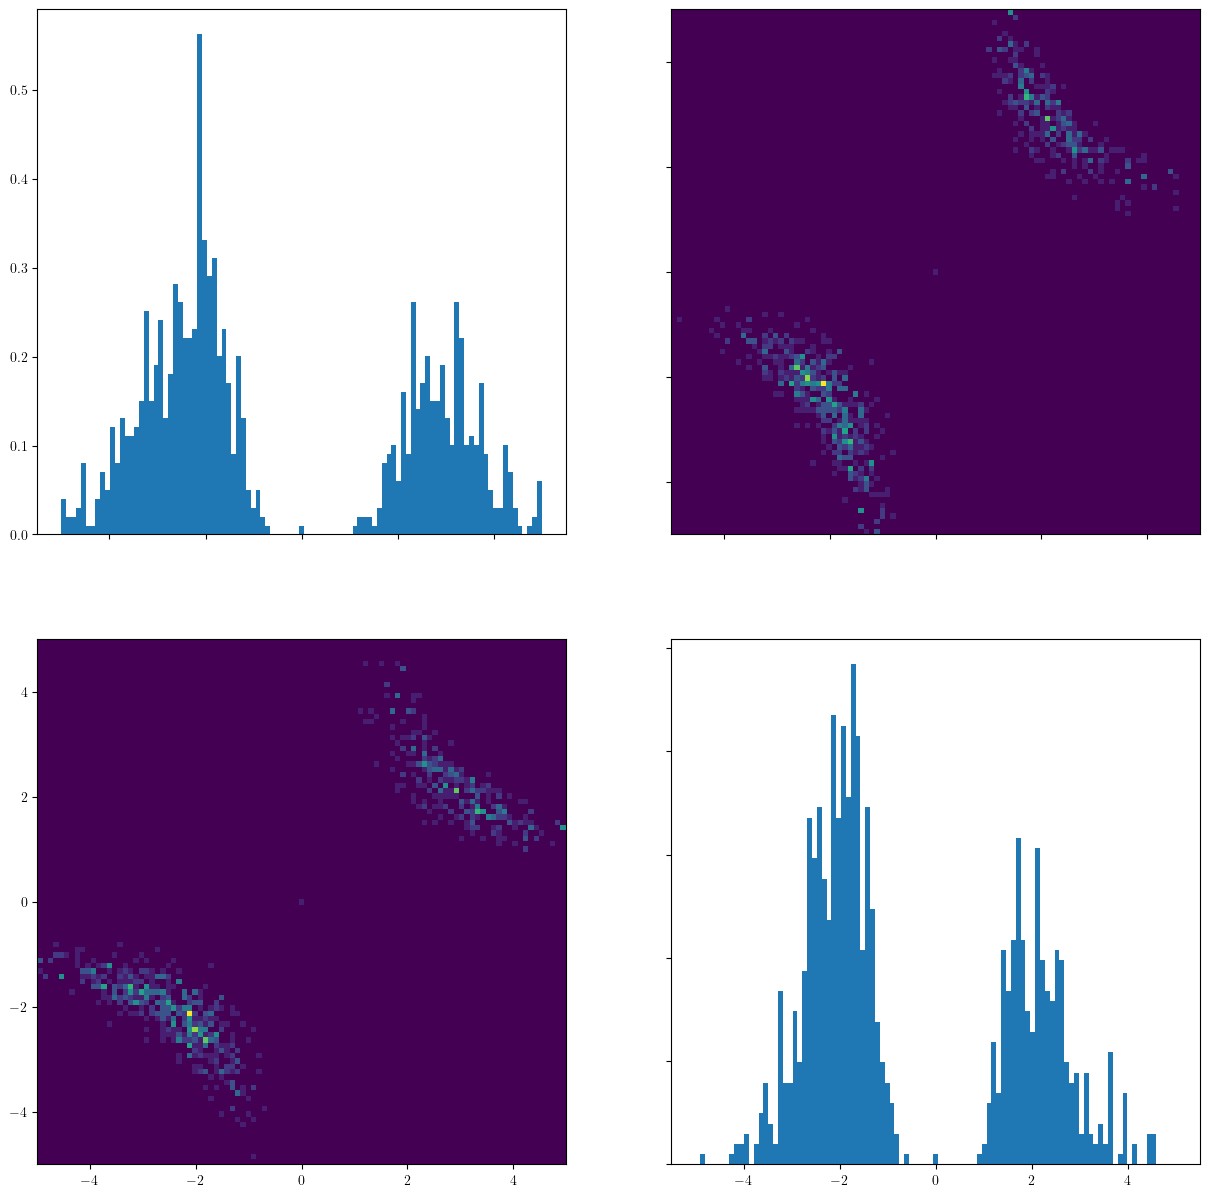

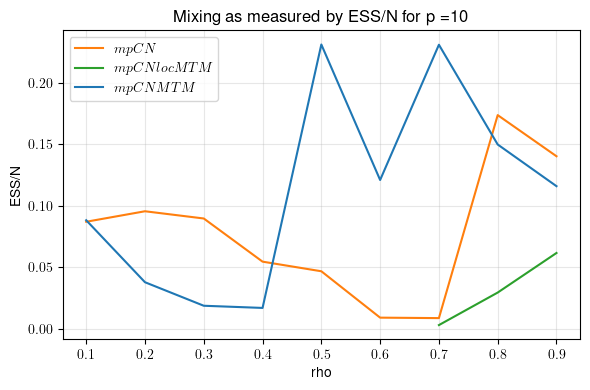

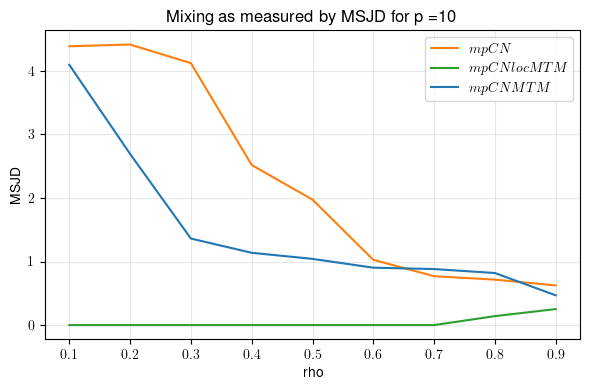

Currently running: 100
Delta rho: 0.1
Number of Samples: 1000


  0%|          | 0/9 [00:00<?, ?it/s]

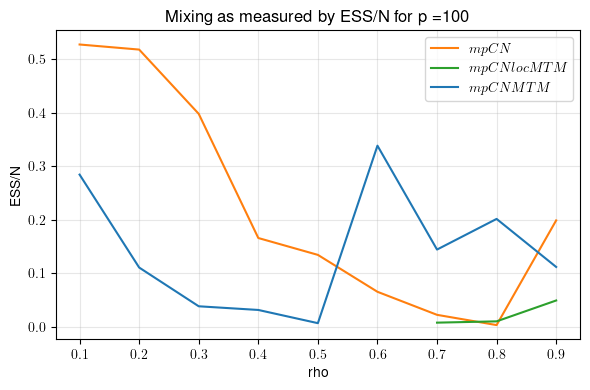

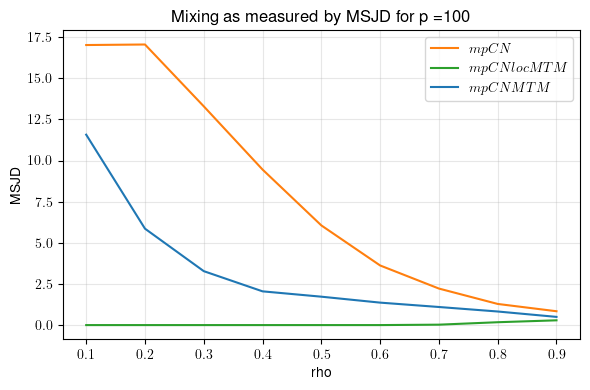

Currently running: 1000
Delta rho: 0.1
Number of Samples: 1000


  0%|          | 0/9 [00:00<?, ?it/s]

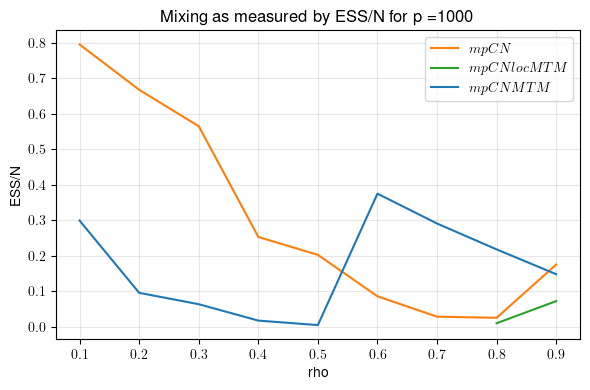

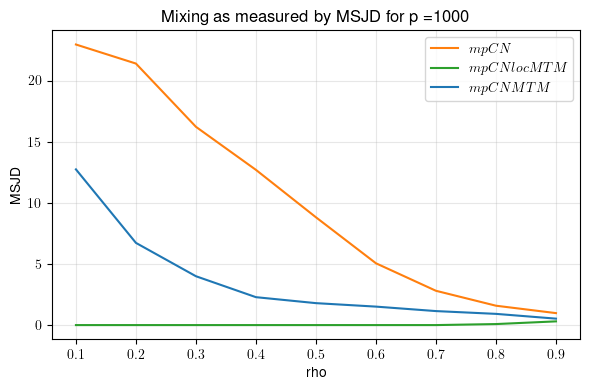

Currently running: 10000
Delta rho: 0.1
Number of Samples: 1000


  0%|          | 0/9 [00:00<?, ?it/s]

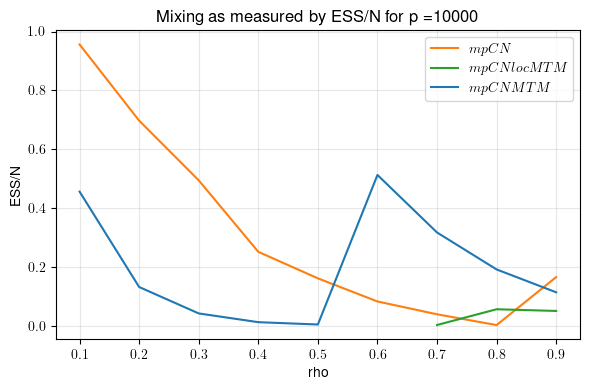

KeyboardInterrupt: 

In [6]:
#Mixing as a function of rho Experiment 1

#Setting up basic location for saving data
FileNmBase= "Data/Large_p_study/Experiment_1/"

#Perform a warm up run
q0 = np.zeros(NumParmsEx2)
rhoWarm = .1
pWarm = 100
numSmpWarm = 100000
WarmSamps = MpCN(q0,NumParmsEx2,CovEx2,rhoWarm,PotEx2,pWarm,numSmpWarm +1)

R = 5
dr = .1

histFileNm = FileNmBase+"Warm_up_HIST.png"

makeHistGrid(R, dr, WarmSamps, NumParmsEx2,histFileNm, False)

q0z = WarmSamps[numSmpWarm]

#Input to studies
#[p,NumRho,NumSamples]

ImpLst = [[10,20,200000],[100,20,200000],[1000,20,200000],[10000,20,200000]]
#ImpLst = [[10,10,1000],[100,10,1000],[1000,10,1000],[10000,10,1000]]


for Imp in ImpLst:
    pCur = Imp[0]

    NumRho = Imp[1]
    delRho = 1/NumRho
    rho = delRho
    NumSamps = Imp[2]
    
    print("Currently running: p=" + str(pCur))
    print("Delta rho: " + str(delRho))
    print("Number of Samples: " + str(NumSamps))

    rhoLst = []
    ESSLstOG = []
    ESSLstLoc = []
    ESSLstGlob = []
    MSJDLstOG = []
    MSJDLstLoc = []
    MSJDLstGlob = []

    
    for curRnInx in tqdm(range(0,NumRho-1)):
        rhoLst.append(rho)
        curSampOG = MpCN(q0z,NumParmsEx2,CovEx2,rho,PotEx2,pCur,NumSamps)
        curSampLoc = locMpCNMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,pCur,NumSamps)
        curSampGlob = MpCNBBMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,pCur,NumSamps)
        ESSLstOG.append(ess(curSampOG[:,0])/NumSamps)
        ESSLstLoc.append(ess(curSampLoc[:,0])/NumSamps)
        ESSLstGlob.append(ess(curSampGlob[:,0])/NumSamps)
        MSJDLstOG.append(msjd(curSampOG))
        MSJDLstLoc.append(msjd(curSampLoc))
        MSJDLstGlob.append(msjd(curSampGlob))
        rho = rho + delRho

    curRunData ="p_" + str(pCur) + "_drho_" + str(delRho) + "_NSamps_" + str(NumSamps)
    csvFileNm = FileNmBase + curRunData +  "_DATA.csv"

    writeCSV(csvFileNm,[rhoLst,ESSLstOG,ESSLstLoc,ESSLstGlob,MSJDLstOG,MSJDLstLoc,MSJDLstGlob])
    

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(rhoLst, ESSLstOG, linestyle="-", label=r"$mpCN$", color="tab:orange")
    ax.plot(rhoLst, ESSLstLoc, linestyle="-", label=r"$mpCNlocMTM$", color="tab:green")
    ax.plot(rhoLst, ESSLstGlob, linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

    ax.set_xlabel(r"rho")
    ax.set_ylabel(r"ESS/N")
    ax.set_title(r"Mixing as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho.png")
    plt.show()


    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(rhoLst, MSJDLstOG, linestyle="-",label=r"$mpCN$", color="tab:orange")
    ax.plot(rhoLst, MSJDLstLoc, linestyle="-",label=r"$mpCNlocMTM$", color="tab:green")
    ax.plot(rhoLst, MSJDLstGlob, linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

    ax.set_xlabel(r"rho")
    ax.set_ylabel(r"MSJD")
    ax.set_title(r"Mixing as measured by MSJD for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_MSJD_v_rho.png")
    plt.show()


In [2]:
#Model Problem 2:  Example 1: From the Parallel MCMC paper

#Importing Needed Functions

#Numerical Set up for AD Toy Model
#AD Toy Model

def MkAD_A_Mat(ModDim, curApar):
    """
    Generates an antisymmetric matric with the given Model Parameters
    """
    A = np.zeros([ModDim,ModDim])
    A[np.triu_indices(ModDim, k=1)] = curApar 
    #triu_indices returns the indices of all the above diagonal indicies
    return A - A.T

def getThA(ModDim, Apar, g, kappa):
    """
    Solves (A + kI) th = g  for theta given the specified model parameters determining A
    """
    A_p_kI = MkAD_A_Mat(ModDim, Apar)+ kappa*np.identity(ModDim)
    return np.linalg.solve(A_p_kI,g)

def mkDiagCov(vrs):
    return np.diag(vrs)


#Code to generate a random orthogonal matrix (uniform from O(n)) using the QR factorization of a Guassian matrix.
def rndm_orth_matrix(n):

    #Generate a random n x n matrix with i.i.d. normal entries
    A = np.random.randn(n, n)
    
    #Perform the QR factorization
    Q, R = np.linalg.qr(A)    
    
    return Q
    

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 4
NumParmsAD = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}

# g = (g0,g1, g2, g3)^T

g0 = .1
g1 = 0
g2 = 5
g3 = 2
g = np.transpose(np.array([g0,g1,g2,g3]))

# Coefficent of the `regularization/diffusion term'
kap = .05

#Specification `observed data' y0, y1
y0 = 4.601
y1 = 18.021

y = [y0,y1]

yData = np.array([y0,y1,0,0])

# `observation noise coefficent'

sig = 2

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(0))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)


Poty = lambda a : (2*sig**2)**(-1)*(norm(y - getThA(ModDm, a, g, kap)[0:2]))**2
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParmsAD+1))]
CovAD = mkDiagCov(CovDiag)

Currently running: p=10
Delta rho: 0.05
Number of Samples: 100000


  0%|          | 0/19 [00:00<?, ?it/s]

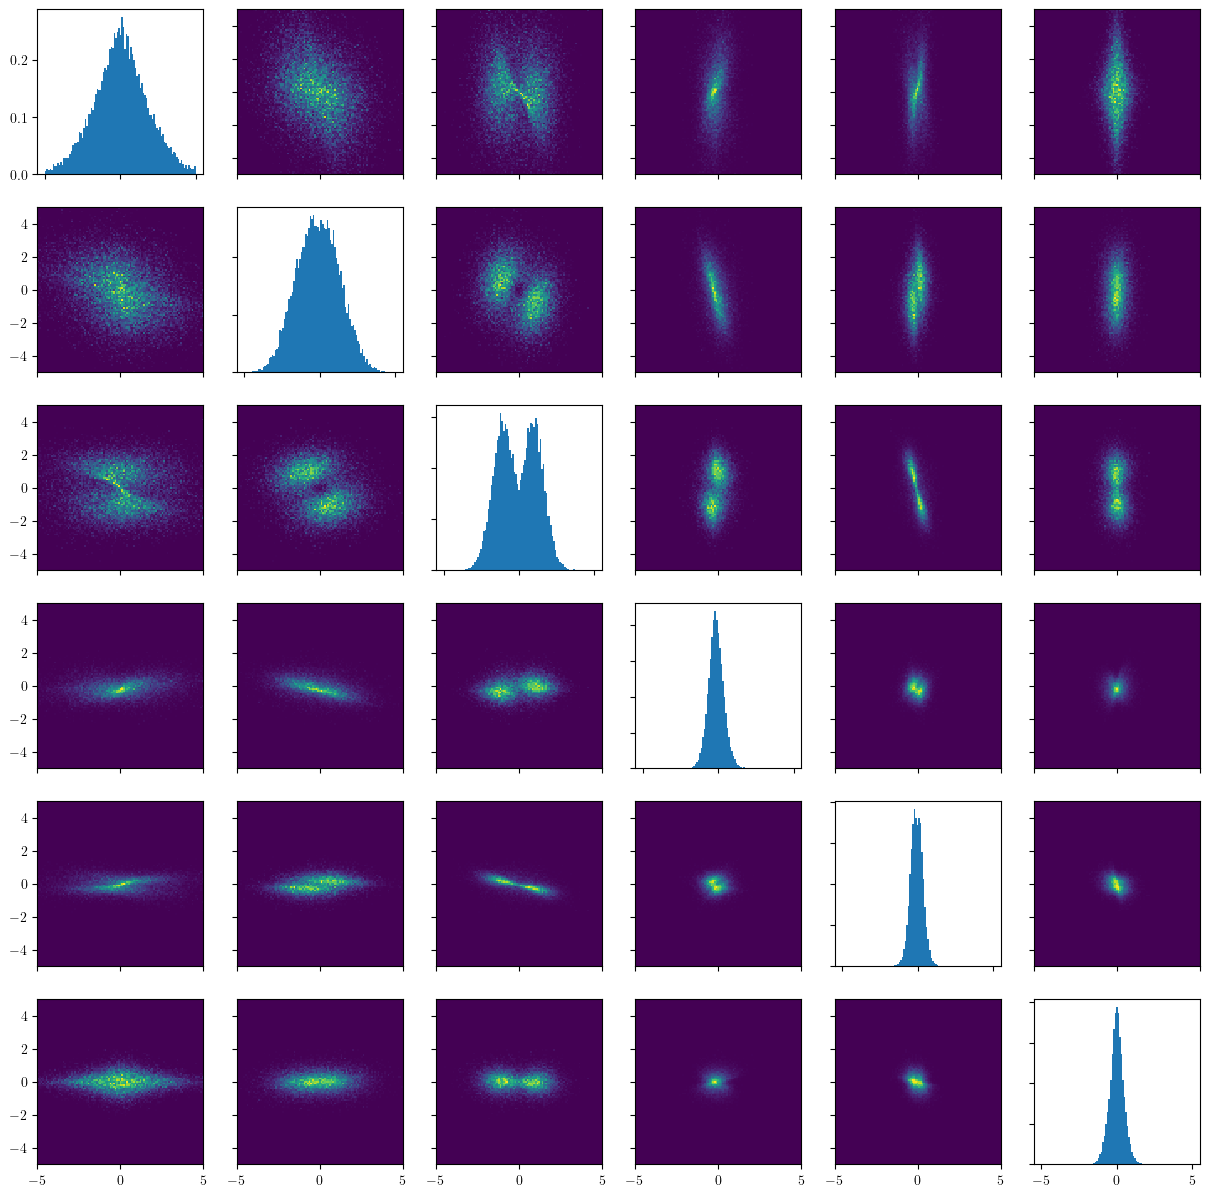

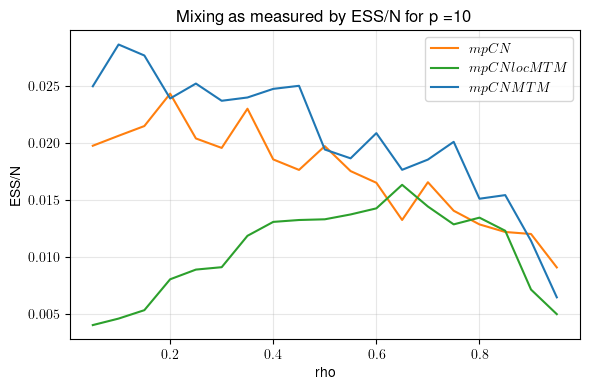

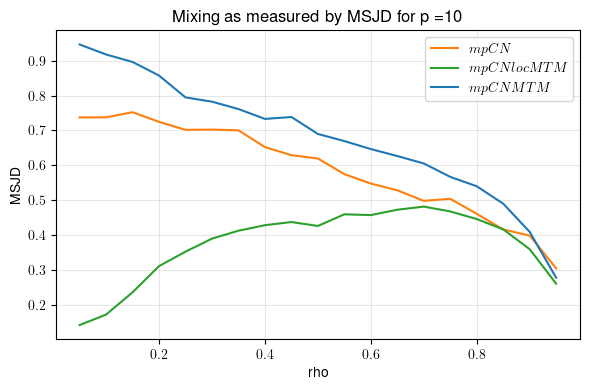

Currently running: p=100
Delta rho: 0.05
Number of Samples: 100000


  0%|          | 0/19 [00:00<?, ?it/s]

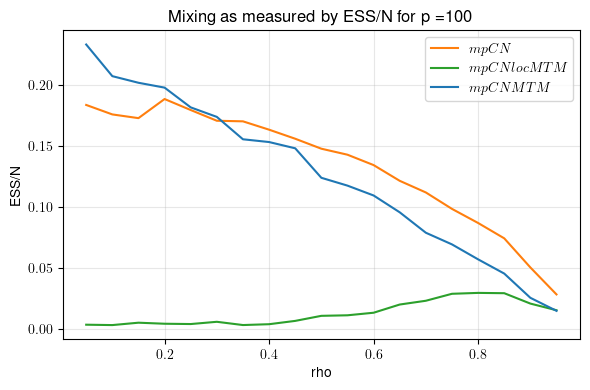

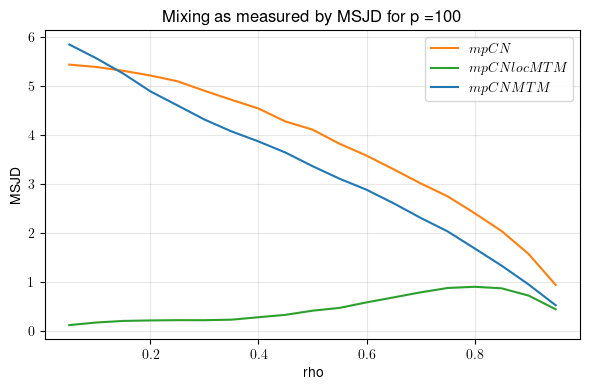

Currently running: p=1000
Delta rho: 0.05
Number of Samples: 100000


  0%|          | 0/19 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [3]:
#Mixing as a function of rho Experiment 2

#Setting up basic location for saving data
FileNmBase= "Data/Large_p_study/Experiment_2/"

#Perform a warm up run
q0ad = np.zeros(NumParmsAD)
rhoWarm = .1
pWarm = 100
numSmpWarm = 100000
WarmSamps = MpCN(q0ad,NumParmsAD,CovAD,rhoWarm,Poty,pWarm,numSmpWarm +1)

R = 5
dr = .1

histFileNm = FileNmBase+"Warm_up_HIST.png"

makeHistGrid(R, dr, WarmSamps, NumParmsAD,histFileNm, False)

q0adWarm = WarmSamps[numSmpWarm]

#Input to studies
#[p,NumRho,NumSamples]

ImpLst = [[10,20,100000],[100,20,100000],[1000,20,100000],[10000,20,50000]]
#ImpLst = [[10,10,1000],[100,10,1000],[1000,10,1000]]


for Imp in ImpLst:
    pCur = Imp[0]

    NumRho = Imp[1]
    delRho = 1/NumRho
    rho = delRho
    NumSamps = Imp[2]
    
    print("Currently running: p=" + str(pCur))
    print("Delta rho: " + str(delRho))
    print("Number of Samples: " + str(NumSamps))

    rhoLst = []
    ESSLstOG = []
    ESSLstLoc = []
    ESSLstGlob = []
    MSJDLstOG = []
    MSJDLstLoc = []
    MSJDLstGlob = []

    
    for curRnInx in tqdm(range(0,NumRho-1)):
        rhoLst.append(rho)
        curSampOG = MpCN(q0adWarm,NumParmsAD,CovAD,rho,Poty,pCur,NumSamps)
        curSampLoc = locMpCNMTM(q0adWarm,NumParmsAD,CovAD,rho,Poty,pCur,NumSamps)
        curSampGlob = MpCNBBMTM(q0adWarm,NumParmsAD,CovAD,rho,Poty,pCur,NumSamps)
        ESSLstOG.append(ess(curSampOG[:,0])/NumSamps)
        ESSLstLoc.append(ess(curSampLoc[:,0])/NumSamps)
        ESSLstGlob.append(ess(curSampGlob[:,0])/NumSamps)
        MSJDLstOG.append(msjd(curSampOG))
        MSJDLstLoc.append(msjd(curSampLoc))
        MSJDLstGlob.append(msjd(curSampGlob))
        rho = rho + delRho

    curRunData ="p_" + str(pCur) + "_drho_" + str(delRho) + "_NSamps_" + str(NumSamps)
    csvFileNm = FileNmBase + curRunData +  "_DATA.csv"

    writeCSV(csvFileNm,[rhoLst,ESSLstOG,ESSLstLoc,ESSLstGlob,MSJDLstOG,MSJDLstLoc,MSJDLstGlob])
    

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(rhoLst, ESSLstOG, linestyle="-", label=r"$mpCN$", color="tab:orange")
    ax.plot(rhoLst, ESSLstLoc, linestyle="-", label=r"$mpCNlocMTM$", color="tab:green")
    ax.plot(rhoLst, ESSLstGlob, linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

    ax.set_xlabel(r"rho")
    ax.set_ylabel(r"ESS/N")
    ax.set_title(r"Mixing as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho.png")
    plt.show()


    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(rhoLst, MSJDLstOG, linestyle="-",label=r"$mpCN$", color="tab:orange")
    ax.plot(rhoLst, MSJDLstLoc, linestyle="-",label=r"$mpCNlocMTM$", color="tab:green")
    ax.plot(rhoLst, MSJDLstGlob, linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

    ax.set_xlabel(r"rho")
    ax.set_ylabel(r"MSJD")
    ax.set_title(r"Mixing as measured by MSJD for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_MSJD_v_rho.png")
    plt.show()
